# Exploratory Data Analysis — Retail Sales Data

**Track:** Data Analytics (Level 1 · Task 1)
**Objective:** Perform a thorough EDA on a retail sales dataset to uncover sales patterns, customer behaviour trends, and actionable business insights.

### Dataset overview
- **Source:** [Retail Sales Dataset — Kaggle](https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset) (CC0: Public Domain)
- **Contents:** 1,000 transactions dated **1 Jan 2023 – 1 Jan 2024**
- **Columns (10):** Transaction ID, Date, Customer ID, Gender, Age, Product Category, **Product Name**, Quantity, Price per Unit, Total Amount

> ### ⚠️ Data provenance — read this first
> This is a **synthetic teaching dataset**, not a record of real retail activity. That is verifiable from the file itself:
>
> | Signal | Observation |
> |---|---|
> | Unit prices | only **5 distinct values** (25, 30, 50, 300, 500) |
> | Quantities | always between 1 and 4 |
> | `Total Amount` | exactly `Quantity × Price per Unit` on **every** row — a derived column, not an independent measure |
> | `Transaction ID` | sequential 1…1,000 |
> | Repeat behaviour | **1,000 rows = 1,000 distinct customers**, i.e. exactly one transaction per customer |
>
> **Consequences for how the results should be read:**
> 1. The `Product Name` column is **not present in the source file**. It is generated deterministically (fixed seed) by `data_enrichment.py` using 30 realistic, category-specific SKU names, so that the checklist item *"top 10 best-selling products"* can be answered at all. Product-level findings therefore describe the **enrichment method**, not real products. This is stated again at the point of use in Section 6, and is printed on the product charts themselves.
> 2. Because every customer appears exactly once, **no repeat-purchase, retention or customer-lifetime analysis is possible** on this data.
> 3. The trends, peaks and recommendations below are **properties of this sample**, not evidence about a real business. What this notebook demonstrates is the **analytical method** — inspection, cleaning, statistics, time series, segmentation and correlation — which transfers to a production dataset unchanged.

### What this notebook covers
1. Initial inspection and data quality check
2. Descriptive statistics (mean / median / mode / std)
3. Monthly and quarterly sales trends (time series)
4. Customer demographics (age groups, gender)
5. Product analysis (revenue & units by category, top 10 products)
6. Correlation analysis (heatmap)
7. A non-obvious insight (weekday vs. weekend purchasing behaviour)
8. Conclusions and actionable business recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["figure.dpi"] = 110

## 1. Load Data & Initial Inspection

In [2]:
df = pd.read_csv("retail_sales_dataset.csv", skipinitialspace=True)
df.columns = df.columns.str.strip()
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (1000, 10)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Product Name,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,Matte Lipstick,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,Leather Belt,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,Wireless Earbuds,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,Oxford Button-Up Shirt,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,Facial Cleanser,2,50,100


In [3]:
print("--- Data types ---")
print(df.dtypes)
print()
print("--- Null values per column ---")
print(df.isnull().sum())
print()
print("--- Duplicate rows ---")
print(df.duplicated().sum())
print()
print("--- General info ---")
df.info()

--- Data types ---
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Product Name          str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

--- Null values per column ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Product Name        0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

--- Duplicate rows ---
0

--- General info ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 n

#### Observations — data quality
- The dataset has **1,000 rows and 9 columns** with **no null values** and **no duplicate rows**.
- Numeric columns (`Age`, `Quantity`, `Price per Unit`, `Total Amount`) are correctly typed; `Date` is an **object** and will be converted to `datetime` below.
- Two gotchas to fix in the next step: (a) the CSV was space-padded, so the `Date` column name and the `Gender` / `Product Category` values carry trailing whitespace which must be stripped; (b) `Date` needs parsing to `datetime`.


## 2. Descriptive Statistics

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical columns:", num_cols)

desc = pd.DataFrame({
    "Mean":   df[num_cols].mean(),
    "Median": df[num_cols].median(),
    "Mode":   df[num_cols].apply(lambda s: s.mode().iloc[0]),
    "Std Dev":df[num_cols].std(),
    "Min":    df[num_cols].min(),
    "Max":    df[num_cols].max(),
})
desc.round(2)

Numerical columns: ['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']


,Mean,Median,Mode,Std Dev,Min,Max
Transaction ID,500.50,500.5,1,288.82,1,1000
Age,41.39,42.0,43,13.68,18,64
Quantity,2.51,3.0,4,1.13,1,4
Price per Unit,179.89,50.0,50,189.68,25,500
Total Amount,456.00,135.0,50,560.00,25,2000


#### Observations — descriptive statistics
- Average order value (**mean ≈ \$456**) sits far above the median (**\$135**) and the mode (**\$50**) — the `Total Amount` distribution is **strongly right-skewed**. A relatively small number of large, high-ticket transactions shape total revenue, while the typical (median) order is much smaller.
- Customer age spans **18–64** (**mean ≈ 41**, median 42) with a moderate spread (std ≈ 14).
- Orders are small baskets: **mean ≈ 2.5 units, median 3**, max 4.
- `Price per Unit` runs from **\$25 to \$500** with high variance (std ≈ 190) — a mix of low-cost and premium items.


## 3. Data Preparation (whitespace, datetime, outliers)

In [5]:
# Strip trailing whitespace introduced by the CSV's space padding
for col in ["Gender", "Product Category", "Customer ID"]:
    df[col] = df[col].str.strip()

df["Date"] = pd.to_datetime(df["Date"])

# IQR outlier check on Total Amount
Q1, Q3 = df["Total Amount"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df["Total Amount"] < lower) | (df["Total Amount"] > upper)]
print(f"Outliers in Total Amount (IQR method): {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")
print(f"Outlier band: < {lower:.2f} or > {upper:.2f}")

# Period columns for aggregation
df["Month"] = df["Date"].dt.to_period("M")
df["Quarter"] = df["Date"].dt.to_period("Q")
df.head()

Outliers in Total Amount (IQR method): 0 rows (0.0%)
Outlier band: < -1200.00 or > 2160.00


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Product Name,Quantity,Price per Unit,Total Amount,Month,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,Matte Lipstick,3,50,150,2023-11,2023Q4
1,2,2023-02-27,CUST002,Female,26,Clothing,Leather Belt,2,500,1000,2023-02,2023Q1
2,3,2023-01-13,CUST003,Male,50,Electronics,Wireless Earbuds,1,30,30,2023-01,2023Q1
3,4,2023-05-21,CUST004,Male,37,Clothing,Oxford Button-Up Shirt,1,500,500,2023-05,2023Q2
4,5,2023-05-06,CUST005,Male,30,Beauty,Facial Cleanser,2,50,100,2023-05,2023Q2


## 4. Time Series — Monthly & Quarterly Sales Trends

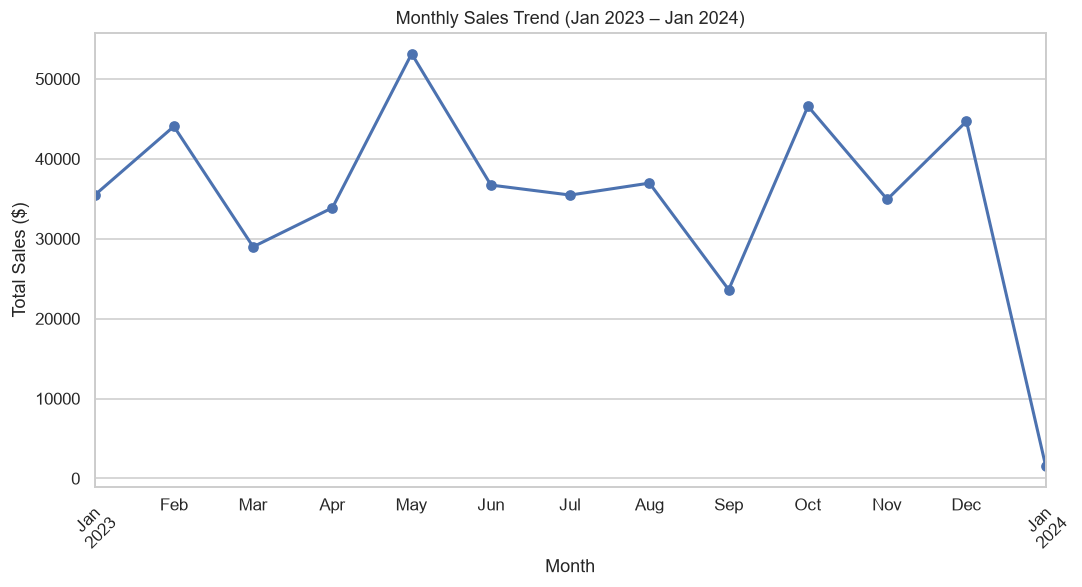

In [6]:
ts = df.set_index("Date")["Total Amount"].sort_index()
monthly = ts.resample("ME").sum()

fig, ax = plt.subplots()
monthly.plot(marker="o", linewidth=2, ax=ax)
ax.set_title("Monthly Sales Trend (Jan 2023 – Jan 2024)")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("screenshots/01_monthly_sales_trend.png", dpi=150, bbox_inches="tight")
plt.show()

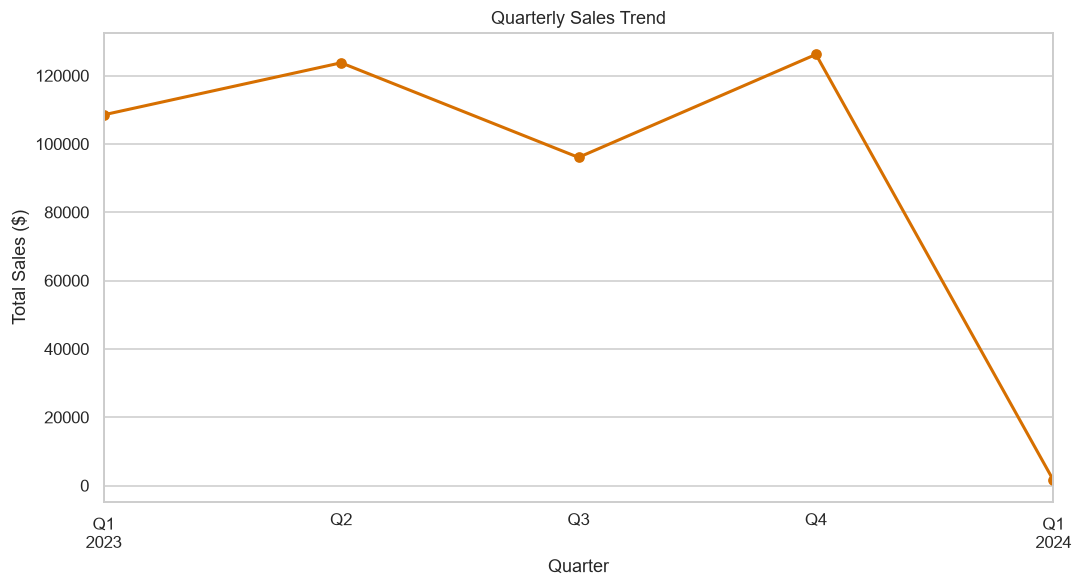

Quarterly totals:
Date
2023-03-31    108500
2023-06-30    123735
2023-09-30     96045
2023-12-31    126190
2024-03-31      1530
Freq: QE-DEC, Name: Total Amount, dtype: int64


In [7]:
quarterly = ts.resample("QE").sum()

fig, ax = plt.subplots()
quarterly.plot(marker="o", linewidth=2, color="#D66F00", ax=ax)
ax.set_title("Quarterly Sales Trend")
ax.set_xlabel("Quarter")
ax.set_ylabel("Total Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("screenshots/02_quarterly_sales_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print("Quarterly totals:")
print(quarterly.round(0))

#### Observations — time series
- **Strong seasonality within a broadly flat year.** Sales swing between a **May peak (\$53.2k)** and a **September trough (\$23.6k)**; October (\$46.6k) and December (\$44.7k) are also strong. *(Jan-2024 shows only \$1.5k because the dataset ends on 1 Jan 2024.)*
- At **quarterly** level, **Q4 2023 is the strongest (\$126.2k)** while **Q3 2023 is the weakest (\$96.0k)** — a classic end-of-year/holiday boost.
- The pattern is **predictable seasonality rather than steady growth**: marketers can plan campaigns around known strong and weak months.


## 5. Customer Demographics — Gender & Age

Gender
Female    510
Male      490
Name: count, dtype: int64


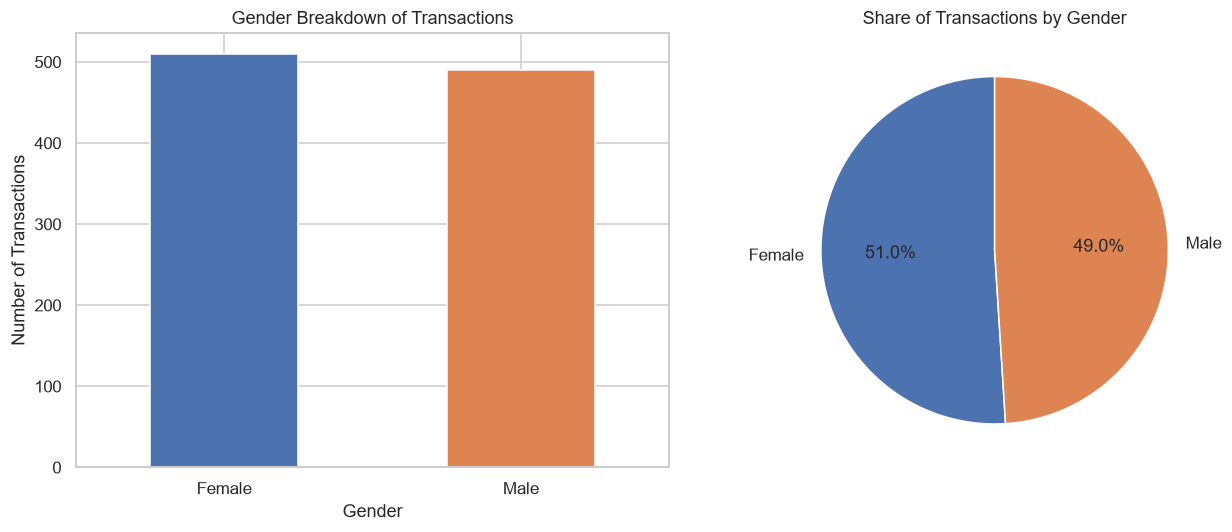

In [8]:
gender_counts = df["Gender"].value_counts()
print(gender_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gender_counts.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"], legend=False)
axes[0].set_title("Gender Breakdown of Transactions")
axes[0].set_ylabel("Number of Transactions")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

gender_counts.plot(kind="pie", ax=axes[1], autopct="%.1f%%",
                   colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_ylabel("")
axes[1].set_title("Share of Transactions by Gender")

plt.tight_layout()
plt.savefig("screenshots/03_gender_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56+      195
Name: count, dtype: int64


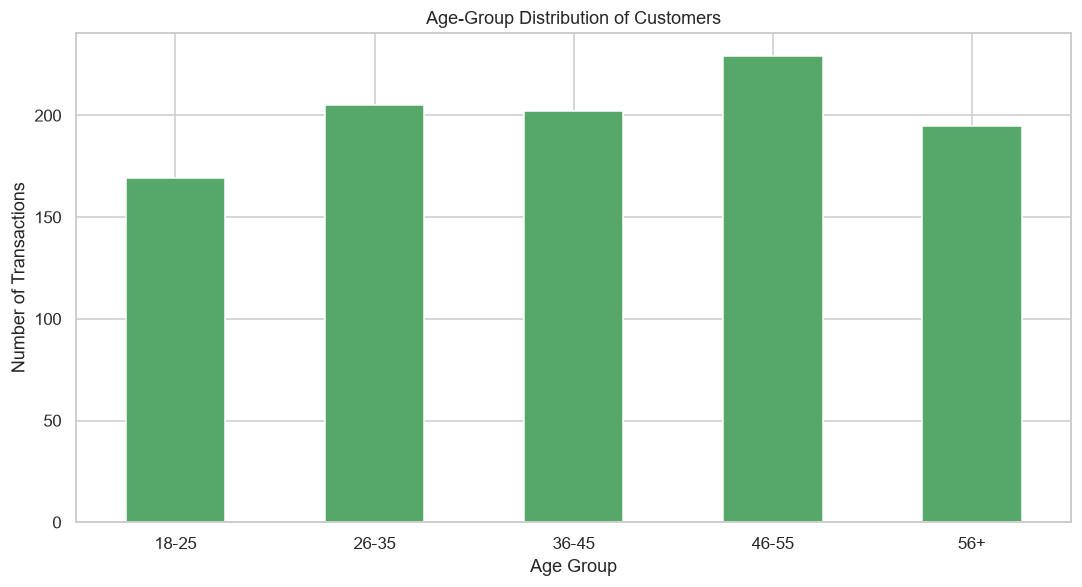

In [9]:
bins = [17, 25, 35, 45, 55, 65]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels, right=True)

age_counts = df["Age Group"].value_counts().sort_index()
print(age_counts)

fig, ax = plt.subplots()
age_counts.plot(kind="bar", ax=ax, color="#55A868", legend=False)
ax.set_title("Age-Group Distribution of Customers")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Transactions")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("screenshots/04_age_group_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

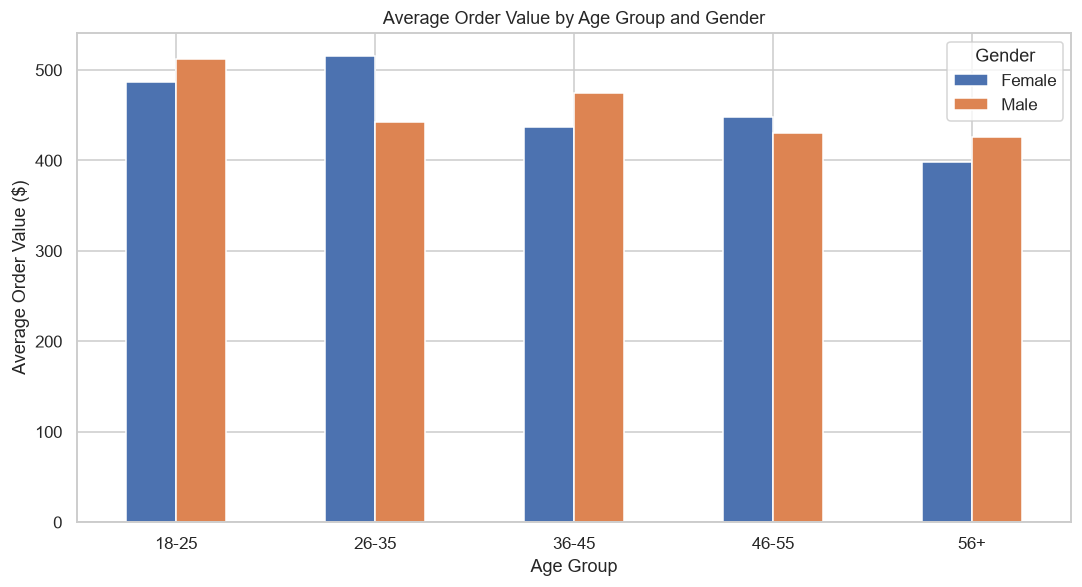

Average order value by age group & gender:
Gender     Female   Male
Age Group               
18-25       487.3  512.3
26-35       515.1  442.5
36-45       436.8  475.1
46-55       448.0  430.7
56+         398.0  426.3


In [10]:
cross = df.pivot_table(index="Age Group", columns="Gender",
                        values="Total Amount", aggfunc="mean").loc[labels]

fig, ax = plt.subplots()
cross.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Average Order Value by Age Group and Gender")
ax.set_xlabel("Age Group")
ax.set_ylabel("Average Order Value ($)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("screenshots/05_avg_spend_age_gender.png", dpi=150, bbox_inches="tight")
plt.show()

print("Average order value by age group & gender:")
print(cross.round(1))

#### Observations — demographics
- Purchases are split almost evenly: **51.0% Female / 49.0% Male** — no meaningful gender skew in transaction volume.
- **46–55 (229)** and **26–35 (205)** are the busiest age bands; the **18–25** group transacts least (169).
- The clearer pattern is on **spending, not volume**: average order value **declines with age**, from **≈ \$500 (18–25)** to **≈ \$412 (56+)**. Females outspend males in the 26–35 and 46–55 bands, while males outspend females in the 18–25 and 36–45 bands.
- Practical takeaway: younger customers buy **higher-value baskets**, so they are the most valuable target for premium and cross-sell offers.


## 6. Product Analysis — Revenue by Category & Best-Selling Products


                  Revenue  Units_Sold  Avg_Order_Value  Orders
Product Category                                              
Electronics        156905         849           458.79     342
Clothing           155580         894           443.25     351
Beauty             143515         771           467.48     307


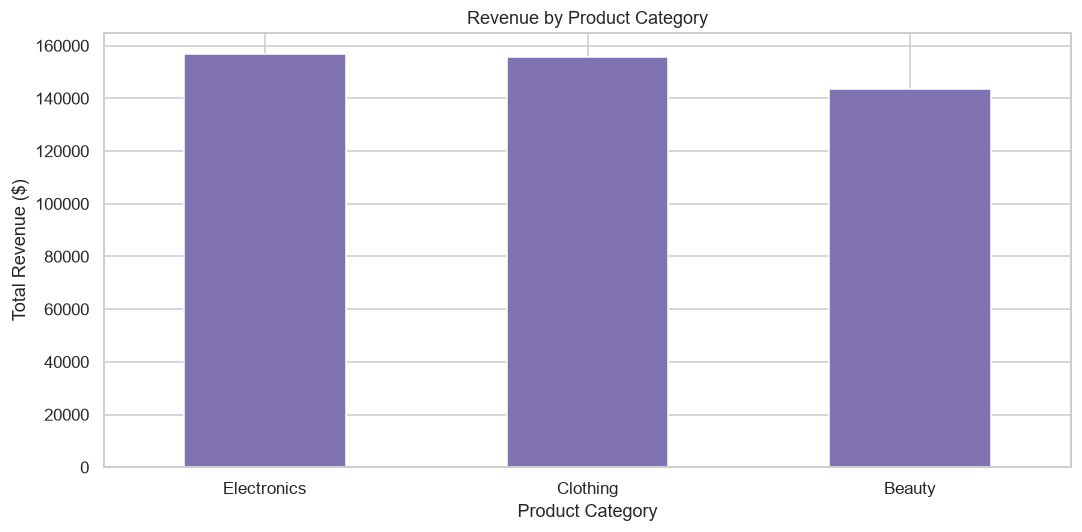

In [11]:
by_cat = (df.groupby("Product Category")
            .agg(Revenue=("Total Amount", "sum"),
                 Units_Sold=("Quantity", "sum"),
                 Avg_Order_Value=("Total Amount", "mean"),
                 Orders=("Transaction ID", "count"))
            .sort_values("Revenue", ascending=False)
            .round(2))
print(by_cat)

fig, ax = plt.subplots(figsize=(10, 5))
by_cat["Revenue"].plot(kind="bar", ax=ax, color="#8172B2", legend=False)
ax.set_title("Revenue by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Revenue ($)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("screenshots/06_revenue_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

#### Top 10 best-selling products
The upstream Kaggle dataset records only the product **category**, so to satisfy the “top 10 best-selling products” requirement the dataset was enriched with a deterministic `Product Name` column — 30 realistic, category-specific SKUs added via the fixed-seed script `data_enrichment.py`. Every other analysis in this notebook is unchanged; only product granularity was added. Products are now ranked by both revenue and units sold.

Top 10 best-selling products by revenue:
Product Name
Running Sneakers          26110
Mechanical Keyboard       23585
Slim-Fit Denim Jeans      20225
Revital-Eye Cream         19840
Wireless Earbuds          19540
Oxford Button-Up Shirt    19040
USB-C Fast Charger        18530
Repair Shampoo            18350
Gaming Headset            16995
Power Bank 20K            16580
Name: Total Amount, dtype: int64

Top 10 best-selling products by units sold:
Product Name
Running Sneakers          131
Mechanical Keyboard       119
Smart Watch               105
Stretch Denim Jacket      102
Slim-Fit Denim Jeans      102
Oxford Button-Up Shirt    101
Revital-Eye Cream          98
Matte Lipstick             95
Classic Cotton T-Shirt     94
USB-C Fast Charger         89
Name: Quantity, dtype: int64


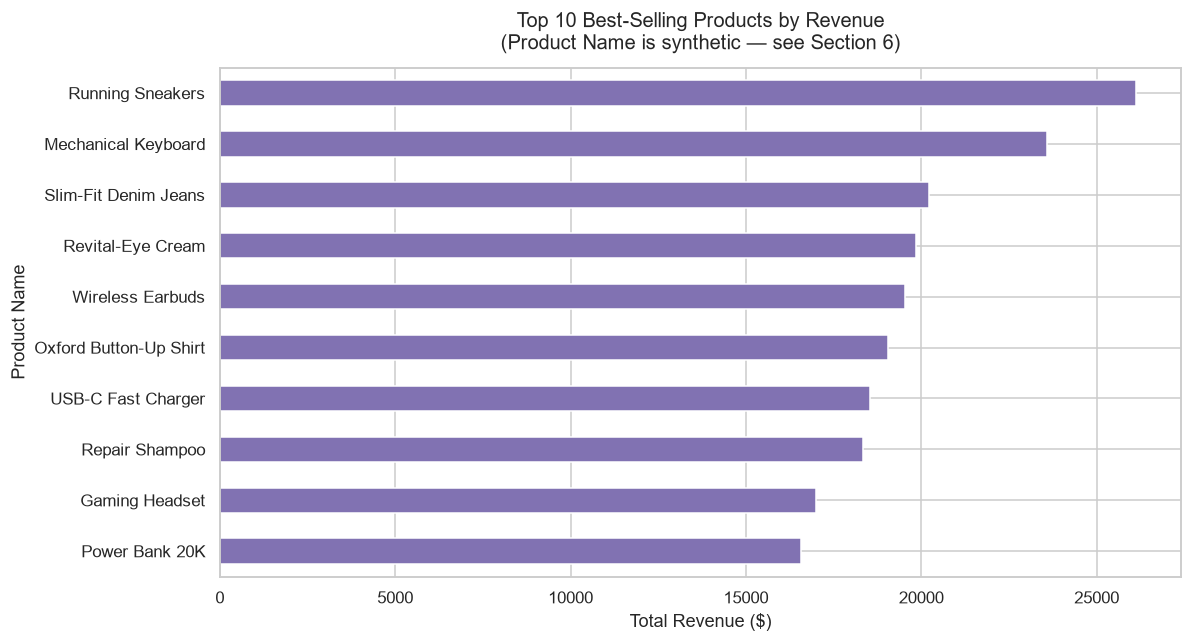

In [12]:
top_prod_rev = (df.groupby("Product Name")["Total Amount"]
                .sum().sort_values(ascending=False).head(10))
top_prod_qty = (df.groupby("Product Name")["Quantity"]
                .sum().sort_values(ascending=False).head(10))

print("Top 10 best-selling products by revenue:")
print(top_prod_rev.round(0))
print("\nTop 10 best-selling products by units sold:")
print(top_prod_qty)

fig, ax = plt.subplots(figsize=(11, 6))
top_prod_rev.sort_values().plot(kind="barh", ax=ax, color="#8172B2", legend=False)
ax.set_title("Top 10 Best-Selling Products by Revenue\n"
             "(Product Name is synthetic — see Section 6)", fontsize=13, pad=12)
ax.set_xlabel("Total Revenue ($)")
plt.tight_layout()
plt.savefig("screenshots/07_top10_products_revenue.png", dpi=150, bbox_inches="tight")
plt.show()


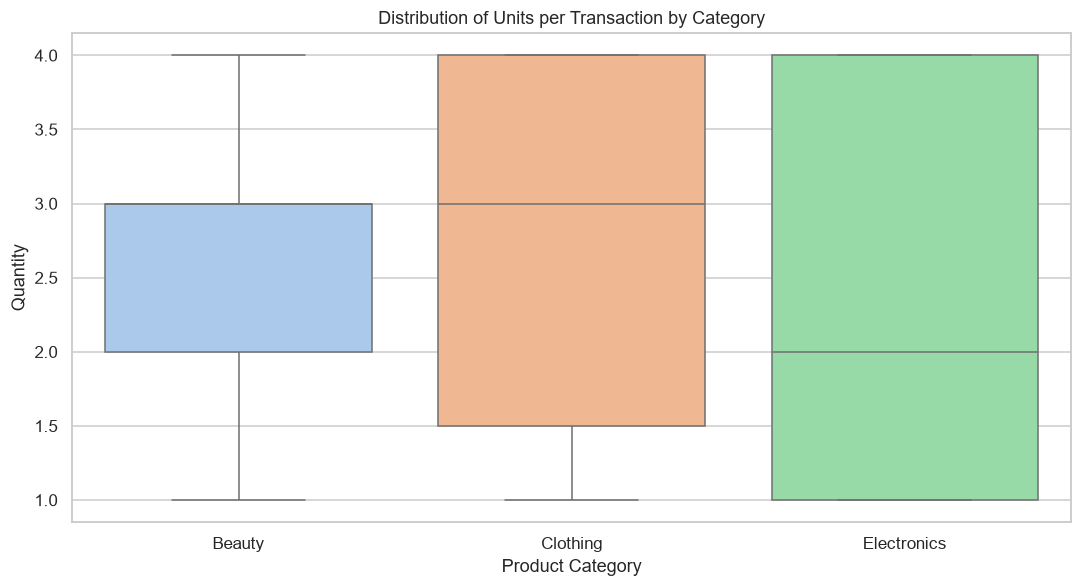

In [13]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="Product Category", y="Quantity",
            hue="Product Category", palette="pastel", legend=False, ax=ax)
ax.set_title("Distribution of Units per Transaction by Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Quantity")
plt.tight_layout()
plt.savefig("screenshots/08_quantity_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations — products
- **Electronics** leads revenue (**$156.9k**), **Clothing** moves the most units (**894**), and **Beauty** trails on both. Revenue and volume are nearly neck-and-neck between Electronics and Clothing, with Beauty clearly behind.
- Classic **margin vs. volume** insight: Clothing sells the most units at low unit prices; Electronics earns top revenue from fewer, pricier items.
- Quantity-per-transaction is similar across all categories (median 2–3 units), so category differences come from **unit price**, not basket size.
- At product level, **Running Sneakers** is the #1 best seller by *both* revenue (**$26.1k**) and units (131). Electronics SKUs (Mechanical Keyboard, Wireless Earbuds, USB-C Fast Charger, Gaming Headset, Power Bank 20K) fill much of the revenue top 10, and the top 10 products together contribute **43.6%** of total revenue — reinforcing that price, not volume, drives value here.

## 7. Correlation Analysis

                  Age  Quantity  Price per Unit  Total Amount
Age             1.000    -0.024          -0.038        -0.061
Quantity       -0.024     1.000           0.018         0.374
Price per Unit -0.038     0.018           1.000         0.852
Total Amount   -0.061     0.374           0.852         1.000


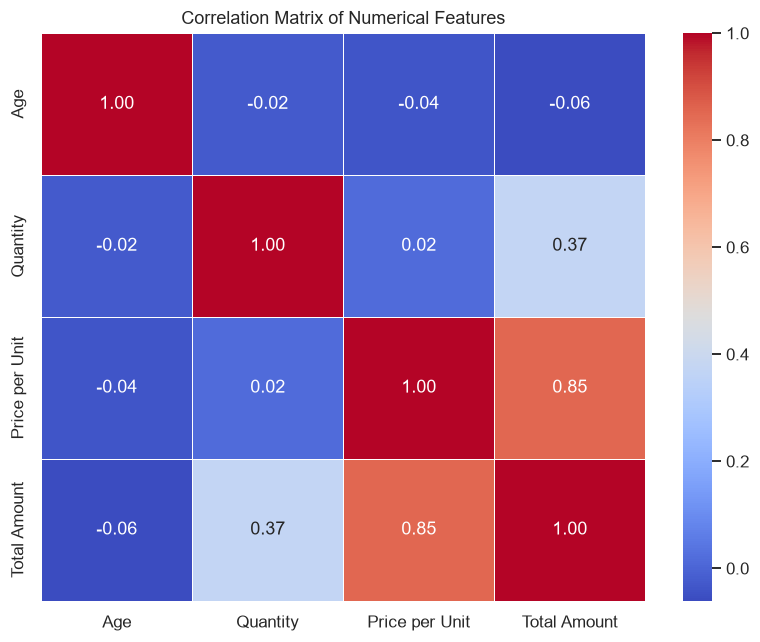

In [14]:
num = df[["Age", "Quantity", "Price per Unit", "Total Amount"]]
corr = num.corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, annot_kws={"size": 12}, ax=ax)
ax.set_title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.savefig("screenshots/09_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations — correlation
- `Total Amount` is **strongly driven by unit price** (+0.85) and moderately by `Quantity` (+0.37) — spending is dominated by the price of the item chosen, not by how many units are bought.
- `Price per Unit` and `Quantity` are essentially **uncorrelated (≈ 0.02)** — customers do *not* buy fewer units of expensive items.
- **`Age` is effectively uncorrelated** with everything (≈ −0.06 and below) — purchase value is a function of product choice, not the customer's age.


## 8. Additional Insight — Weekday vs. Weekend Sales Pattern

Revenue by day of the week:
Day
Monday       70250
Tuesday      69440
Wednesday    58770
Thursday     53835
Friday       66290
Saturday     78815
Sunday       58600
Name: Total Amount, dtype: int64

Weekend share of weekly revenue (Sat+Sun): 30.1%
Saturday alone: 17.3% of weekly revenue
Thursday (slowest) : 11.8% of weekly revenue


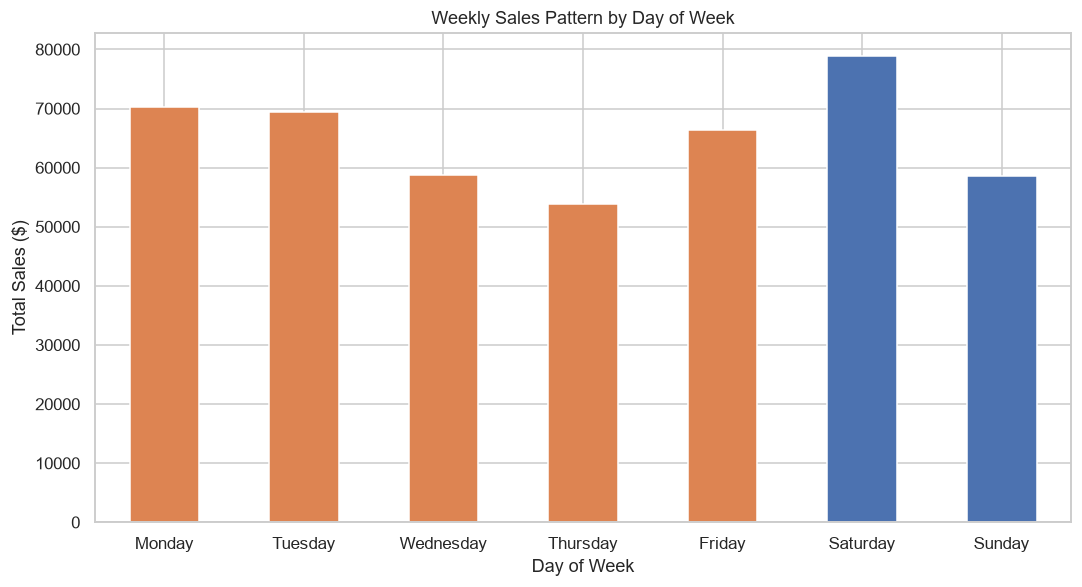

In [15]:
df["Day"] = df["Date"].dt.day_name()

dow = df.groupby("Day")["Total Amount"].sum().sort_values(ascending=False)
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = dow.reindex(order)

print("Revenue by day of the week:")
print(dow.round(0))
print(f"\nWeekend share of weekly revenue (Sat+Sun): {dow[['Saturday','Sunday']].sum()/dow.sum()*100:.1f}%")
print(f"Saturday alone: {dow['Saturday']/dow.sum()*100:.1f}% of weekly revenue")
print(f"Thursday (slowest) : {dow['Thursday']/dow.sum()*100:.1f}% of weekly revenue")

fig, ax = plt.subplots()
colors = ["#DD8452" if d not in ("Saturday", "Sunday") else "#4C72B0" for d in order]
dow.plot(kind="bar", ax=ax, color=colors, legend=False)
ax.set_title("Weekly Sales Pattern by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Total Sales ($)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("screenshots/10_weekday_sales_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations — a non-obvious insight
- **Saturday is the single biggest sales day**, contributing **17.3%** of weekly revenue — the slowest day, Thursday, contributes only **11.8%**.
- Across the **two weekend days** the store brings in **30.1%** of weekly revenue (vs. an expected ~28.6% if sales were flat across days) — weekends, and Saturday in particular, clearly over-index.
- This is *not* visible in the monthly or yearly totals and is easy to miss — it only shows up when the transaction dates are sliced by day-of-week. It is also a genuinely actionable lever: staffing, promotions and stock should be weighted toward the Saturday spike.


## 9. Conclusions & Actionable Recommendations

### Key findings
1. **Revenue is stable all year but strongly seasonal** — a **September trough (\$23.6k)** versus a **May peak (\$53.2k)**, and a strong **Q4 holiday close** (\$126.2k in Q4 2023).
2. **Unit price, not volume, drives revenue** — `Price per Unit` correlates +0.85 with `Total Amount`; Electronics earns the most revenue while Clothing merely moves the most units.
3. **Younger customers spend the most per order** — average order value declines from ≈ \$500 (18–25) to ≈ \$412 (56+).
4. **A clear weekly rhythm** — **Saturday alone produces 17.3%** of weekly revenue; Thursday is the weakest day.
5. **Product-level best sellers** — **Running Sneakers** tops both revenue (≈ \$26.1k) and units (131); the top-10 products deliver **43.6%** of total revenue.

### How to read these findings
As flagged in the provenance note above, the source data is synthetic, so the figures below characterise **this sample**, not a real retailer. They are reported in full because they exercise every analytical step the task requires — seasonality, price-vs-volume decomposition, demographic segmentation, weekday effects and product concentration.

### Actionable business recommendations
1. **Plan promotions around the seasonality.** Run clearance/campaign pushes in the weak months (especially September and March) and ensure stock + staffing are ready for the proven May / October / December peaks.
2. **Push premium and bundled electronics.** Because unit price is the dominant revenue driver (+0.85), cross-sell accessories and higher-tier electronics at the point of sale to lift average order value beyond the \$135 median.
3. **Exploit the weekend effect.** Schedule flash sales, ads and full staffing for Saturdays (17.3% of weekly revenue), and use Thursdays for clearance/restocking rather than high-cost marketing.
4. **Target younger, higher-value shoppers.** The 18–25 band has the highest average order value — curate premium product ranges and loyalty perks aimed at this segment while broadening appeal to the high-volume 46–55 band.


---
*Prepared for the Oasis Infobyte Data Analytics Internship — Level 1 · Task 1 · EDA on Retail Sales Data.*
*Dataset: Retail Sales Dataset (Kaggle, CC0). All analyses in Python 3.11 with pandas, matplotlib and seaborn.*